# Social Factors & Transit Accessibility

In [1]:
import census
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.lines import Line2D
from scipy.stats import pearsonr

In [2]:
# Load Social Vulnerability Index (SVI) data 
svi_df = pd.read_csv("SVI_2022_US.csv").set_index("FIPS")
svi_df.index = svi_df.index.astype(str).str.zfill(11)
svi_df.index.names = ["GEOID"]
svi_df = svi_df[svi_df["RPL_THEMES"] > 0] # Filter out invalid SVI scores 

# Display SVI dataframe  
svi_df.head()

,ST,STATE,ST_ABBR,STCNTY,COUNTY,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,E_HU,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
GEOID,,,,,,,,,,,,,,,,,,,,,
01001020100,1,Alabama,AL,1001,Autauga County,Census Tract 201; Autauga County; Alabama,3.793569,1865,368,733,...,2.4,3.4,0.0,2.0,0.0,2.0,5.5,4.2,0.0,2.0
01001020200,1,Alabama,AL,1001,Autauga County,Census Tract 202; Autauga County; Alabama,1.282174,1861,396,680,...,0.0,2.0,0.0,2.0,0.0,2.0,7.3,6.3,0.4,0.9
01001020300,1,Alabama,AL,1001,Autauga County,Census Tract 203; Autauga County; Alabama,2.065364,3492,593,1431,...,0.3,0.5,0.0,1.1,0.0,1.1,4.2,5.2,0.0,1.1
01001020400,1,Alabama,AL,1001,Autauga County,Census Tract 204; Autauga County; Alabama,2.464984,3987,411,1722,...,0.6,0.6,0.2,0.3,0.0,0.9,2.9,2.6,0.0,0.9
01001020501,1,Alabama,AL,1001,Autauga County,Census Tract 205.01; Autauga County; Alabama,2.395243,4121,709,1857,...,2.4,4.1,0.0,0.9,0.0,0.9,1.0,1.3,0.0,0.9


In [3]:
# Making sure the SVI scale is from 0 to 1 
print(svi_df['RPL_THEMES'].describe())

count    83337.000000
mean         0.500024
std          0.288663
min          0.000100
25%          0.250000
50%          0.500000
75%          0.750000
max          1.000000
Name: RPL_THEMES, dtype: float64


In [4]:
# Load Transit Desert Index data 
tdi_df = pd.read_csv("TDI_v2_1_tract_SVI.csv")
tdi_df.set_index("GEOID", inplace=True)
tdi_df.index = tdi_df.index.astype(str).str.zfill(11)

# Display TDI dataframe 
tdi_df.head()

,OID_,STATE,COUNTY,AREA_SQMI,td_index,td_demand_zscore,td_demand_pop,td_supply_zscore,num_stops,num_intersects,...,E_SNGPNT,E_MINRTY,E_LIMENG,E_NOVEH,RPL_THEME1,RPL_THEME2,RPL_THEME3,RPL_THEME4,Shape_Length,Shape_Area
GEOID,,,,,,,,,,,,,,,,,,,,,
06037265301,1,CALIFORNIA,Los Angeles,0.616146,1.291665,0.830158,11235.0,-0.054162,247,161,...,0,8305,35,0,-999.0000,0.0011,0.5527,-999.0,0.060180,0.000156
06037403200,2,CALIFORNIA,Los Angeles,0.972343,-0.741504,-1.157508,314.0,-0.642704,62,197,...,0,243,67,0,0.7936,0.4692,0.8512,-999.0,0.070250,0.000246
06037574601,3,CALIFORNIA,Los Angeles,0.500673,-0.764948,-0.696636,2241.0,-0.165699,150,215,...,0,1221,6,0,-999.0000,0.0009,0.4861,-999.0,0.058069,0.000127
06053014104,4,CALIFORNIA,Monterey,1.237261,-0.218897,-0.635977,1892.0,-0.432981,134,107,...,0,1083,13,0,-999.0000,0.0018,0.5718,-999.0,0.077233,0.000320
06073003800,5,CALIFORNIA,San Diego,0.692611,0.743325,0.491763,6252.0,-0.103769,49,202,...,0,3264,0,0,-999.0000,-999.0000,0.3382,-999.0,0.073596,0.000172


---

## Research Question:  
### How does social vulnerability (characterized by factors such as poverty, disability, and minority status) correlate with public transit accessibility? 

**Variables:**  
* **_RPL_THEME_**: The percentile ranking (0–1) of overall social vulnerability for each census tract, as defined by the CDC/ATSDR Social Vulnerability Index (SVI). This composite score integrates four themes: Socioeconomic Status, Household Characteristics, Racial & Ethnic Minority Status, and Housing Type & Transportation.
  * **Interpretation:**
     * Higher values indicate greater vulnerability.
* **_td_index_**: Transit Desert Index - A standardized score measuring the gap between level of transit service (supply) and needs of the transportation-dependent population (demand).
  * **Interpretation:**
    * Values > 1: Transit desert (demand exceeds supply)
    * Values < -1: Transit oasis (supply exceeds demand)
    * Values between -1 and 1: Transit adequate (supply ≈ demand)

In [5]:
# Loading New York tract file
ny_tract_gdf = gpd.read_file("ny_tracts/tl_2020_36_tract.shp").set_index("GEOID").to_crs("EPSG:2163")

# Display NY tract gdf 
ny_tract_gdf.head()

,STATEFP,COUNTYFP,TRACTCE,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
GEOID,,,,,,,,,,,,
36047000700,36,047,000700,7,Census Tract 7,G5020,S,176774,0,+40.6923505,-073.9973434,"POLYGON ((2148354.604 -134772.663, 2148358.310..."
36047000900,36,047,000900,9,Census Tract 9,G5020,S,163469,0,+40.6917206,-073.9916018,"POLYGON ((2149011.052 -134777.657, 2149014.262..."
36047001100,36,047,001100,11,Census Tract 11,G5020,S,168507,0,+40.6932903,-073.9877087,"POLYGON ((2149201.759 -134459.311, 2149201.031..."
36047001300,36,047,001300,13,Census Tract 13,G5020,S,293167,0,+40.6976150,-073.9883586,"POLYGON ((2148961.173 -133878.087, 2148950.501..."
36047002000,36,047,002000,20,Census Tract 20,G5020,S,154138,0,+40.6480407,-074.0159276,"POLYGON ((2148513.392 -140093.627, 2148540.771..."


In [6]:
# Merging SVI and TDI dataframes together 
combined_nyc = svi_df.merge(
    tdi_df[["td_index"]],
    left_index=True, 
    right_index=True
)

# Filtering combined_nyc dataframe to only include the 5 boroughs 
boro_names = ["Richmond County", "Bronx County", "New York County", "Kings County", "Queens County"]
combined_nyc = combined_nyc[(combined_nyc["COUNTY"].isin(boro_names)) & (combined_nyc["STATE"] == "New York")]

# Displaying merged SVI and TDI dataframe 
combined_nyc.head()

,ST,STATE,ST_ABBR,STCNTY,COUNTY,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,E_HU,...,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE,td_index
GEOID,,,,,,,,,,,,,,,,,,,,,
36005000200,36,New York,NY,36005,Bronx County,Census Tract 2; Bronx County; New York,0.173014,4870,621,1487,...,7.1,0.0,0.8,0.0,0.8,0.0,0.8,2.0,2.4,0.434717
36005000400,36,New York,NY,36005,Bronx County,Census Tract 4; Bronx County; New York,0.299390,6257,982,2344,...,1.2,0.0,0.6,0.0,0.6,0.6,0.6,1.0,1.5,0.322490
36005001600,36,New York,NY,36005,Bronx County,Census Tract 16; Bronx County; New York,0.187290,6177,618,2205,...,3.0,3.4,3.3,0.0,0.6,1.1,0.9,0.1,0.1,0.535155
36005002300,36,New York,NY,36005,Bronx County,Census Tract 23; Bronx County; New York,0.040404,4528,596,1923,...,0.9,0.0,0.9,0.0,0.9,0.0,0.9,1.1,1.7,1.966899
36005002500,36,New York,NY,36005,Bronx County,Census Tract 25; Bronx County; New York,0.049225,5642,741,1951,...,0.7,0.0,0.7,0.0,0.7,0.9,1.2,0.2,0.4,2.218302


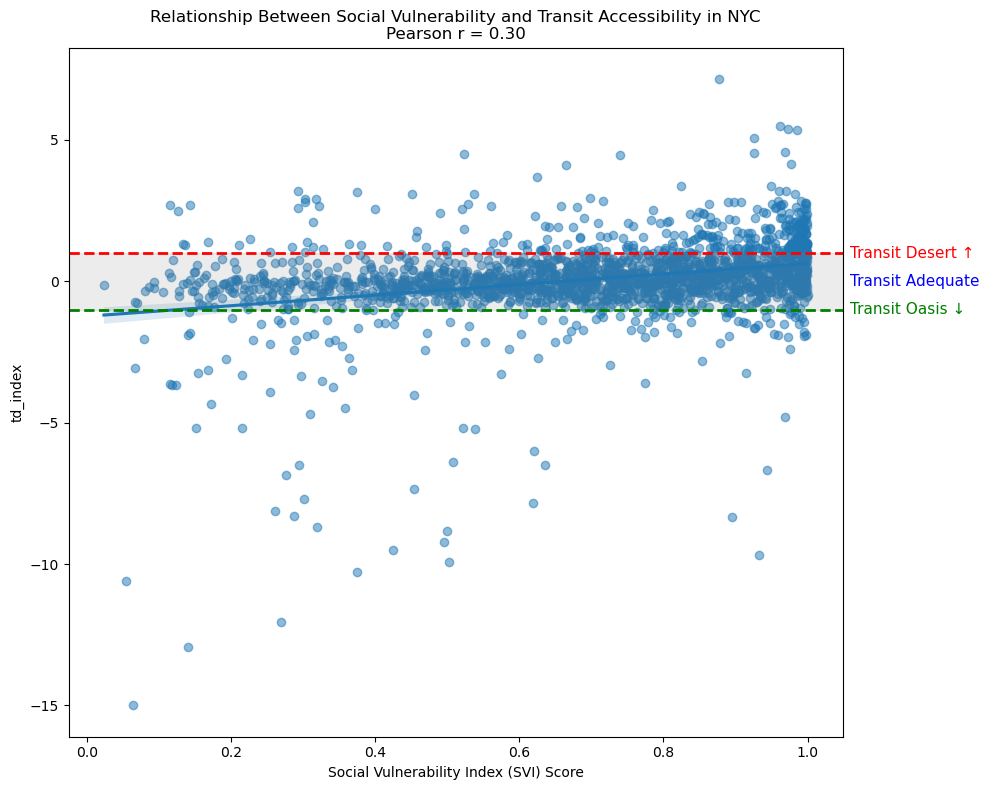

In [7]:
# Calculate Pearson correlation coefficient
r, p = pearsonr(combined_nyc['RPL_THEMES'], combined_nyc['td_index'])

# Create the scatterplot with regression line
plt.figure(figsize=(10, 8))
sns.regplot(
    x='RPL_THEMES',           
    y='td_index',             
    data=combined_nyc,  
    scatter_kws={'alpha':0.5}
)

# Add x & y labels and title
plt.xlabel('Social Vulnerability Index (SVI) Score')
plt.title(f'Relationship Between Social Vulnerability and Transit Accessibility in NYC\nPearson r = {r:.2f}')

# Draw horizontal lines at y = 1 and y = -1
plt.axhline(y=1, color='red', linestyle='--', linewidth=2)
plt.axhline(y=-1, color='green', linestyle='--', linewidth=2)

# Add labels for transit desert, oasis, and adqeuare
plt.text(
    1.01, 1, 'Transit Desert \u2191', color='red', va='center', ha='left', fontsize=11,
    transform=plt.gca().get_yaxis_transform()
)

plt.text(
    1.01, 0, 'Transit Adequate', color='blue', va='center', ha='left', fontsize=11,
    transform=plt.gca().get_yaxis_transform()
)

plt.text(
    1.01, -1, 'Transit Oasis \u2193', color='green', va='center', ha='left', fontsize=11,
    transform=plt.gca().get_yaxis_transform()
)


# Shade the transit adequate region
plt.axhspan(-1, 1, color='gray', alpha=0.15)

# Display the plot 
plt.tight_layout()
plt.show()

---

## Sub-Question 1
### How do spatial patterns of social vulnerability and transit deserts overlap or diverge within urban areas? 


**Variables:**  
* **_RPL_THEME_**: The percentile ranking (0–1) of overall social vulnerability for each census tract, as defined by the CDC/ATSDR Social Vulnerability Index (SVI). This composite score integrates four themes: Socioeconomic Status, Household Characteristics, Racial & Ethnic Minority Status, and Housing Type & Transportation.
  * **Interpretation:**
     * Higher values indicate greater vulnerability.
* **_td_index_**: Transit Desert Index - A standardized score measuring the gap between level of transit service (supply) and needs of the transportation-dependent population (demand).
  * **Interpretation:**
    * Values > 1: Transit desert (demand exceeds supply)
    * Values < -1: Transit oasis (supply exceeds demand)
    * Values between -1 and 1: Transit adequate (supply ≈ demand)


In [8]:
# Isolating for 5 NYC boroughs
boros = ['005', '061', '047', '081', '085']
nyc_zoomed_in = ny_tract_gdf[ny_tract_gdf["COUNTYFP"].isin(boros)]

# Filtering the gdf to exlude large bodies of water
nyc_zoomed_in = nyc_zoomed_in[nyc_zoomed_in["ALAND"] > 0]

# Display NYC (only) dataframe 
nyc_zoomed_in.head()

,STATEFP,COUNTYFP,TRACTCE,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
GEOID,,,,,,,,,,,,
36047000700,36,047,000700,7,Census Tract 7,G5020,S,176774,0,+40.6923505,-073.9973434,"POLYGON ((2148354.604 -134772.663, 2148358.310..."
36047000900,36,047,000900,9,Census Tract 9,G5020,S,163469,0,+40.6917206,-073.9916018,"POLYGON ((2149011.052 -134777.657, 2149014.262..."
36047001100,36,047,001100,11,Census Tract 11,G5020,S,168507,0,+40.6932903,-073.9877087,"POLYGON ((2149201.759 -134459.311, 2149201.031..."
36047001300,36,047,001300,13,Census Tract 13,G5020,S,293167,0,+40.6976150,-073.9883586,"POLYGON ((2148961.173 -133878.087, 2148950.501..."
36047002000,36,047,002000,20,Census Tract 20,G5020,S,154138,0,+40.6480407,-074.0159276,"POLYGON ((2148513.392 -140093.627, 2148540.771..."


In [9]:
# Merging NYC (specifically) with the TDI dataframe
nyc_tdi_zoomed_in = nyc_zoomed_in.merge(
    tdi_df[['td_index']],
    left_index=True,
    right_index=True
)

# Adding a catergorical column for transit accessibility 
nyc_tdi_zoomed_in['transit_category'] = 'Transit Adequate'
nyc_tdi_zoomed_in.loc[nyc_tdi_zoomed_in['td_index'] > 1, 'transit_category'] = 'Transit Desert'
nyc_tdi_zoomed_in.loc[nyc_tdi_zoomed_in['td_index'] < -1, 'transit_category'] = 'Transit Oasis'

# Displaying NYC (only) TDI dataframe 
nyc_tdi_zoomed_in.head()

,STATEFP,COUNTYFP,TRACTCE,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,td_index,transit_category
GEOID,,,,,,,,,,,,,,
36047000700,36,047,000700,7,Census Tract 7,G5020,S,176774,0,+40.6923505,-073.9973434,"POLYGON ((2148354.604 -134772.663, 2148358.310...",-0.036660,Transit Adequate
36047000900,36,047,000900,9,Census Tract 9,G5020,S,163469,0,+40.6917206,-073.9916018,"POLYGON ((2149011.052 -134777.657, 2149014.262...",-0.774297,Transit Adequate
36047001100,36,047,001100,11,Census Tract 11,G5020,S,168507,0,+40.6932903,-073.9877087,"POLYGON ((2149201.759 -134459.311, 2149201.031...",-3.151798,Transit Oasis
36047001300,36,047,001300,13,Census Tract 13,G5020,S,293167,0,+40.6976150,-073.9883586,"POLYGON ((2148961.173 -133878.087, 2148950.501...",-1.373790,Transit Oasis
36047002000,36,047,002000,20,Census Tract 20,G5020,S,154138,0,+40.6480407,-074.0159276,"POLYGON ((2148513.392 -140093.627, 2148540.771...",-0.712774,Transit Adequate


In [10]:
# Merging NYC (specifically) with the SVI dataframe
nyc_svi_zoomed_in = nyc_zoomed_in.merge(
    svi_df[['RPL_THEMES']],
    left_index=True,
    right_index=True
)

# Display the NYC (only) SVI dataframe 
nyc_svi_zoomed_in.head()

,STATEFP,COUNTYFP,TRACTCE,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,RPL_THEMES
GEOID,,,,,,,,,,,,,
36047000700,36,047,000700,7,Census Tract 7,G5020,S,176774,0,+40.6923505,-073.9973434,"POLYGON ((2148354.604 -134772.663, 2148358.310...",0.2598
36047000900,36,047,000900,9,Census Tract 9,G5020,S,163469,0,+40.6917206,-073.9916018,"POLYGON ((2149011.052 -134777.657, 2149014.262...",0.1557
36047001100,36,047,001100,11,Census Tract 11,G5020,S,168507,0,+40.6932903,-073.9877087,"POLYGON ((2149201.759 -134459.311, 2149201.031...",0.1681
36047001300,36,047,001300,13,Census Tract 13,G5020,S,293167,0,+40.6976150,-073.9883586,"POLYGON ((2148961.173 -133878.087, 2148950.501...",0.2656
36047002000,36,047,002000,20,Census Tract 20,G5020,S,154138,0,+40.6480407,-074.0159276,"POLYGON ((2148513.392 -140093.627, 2148540.771...",0.9753


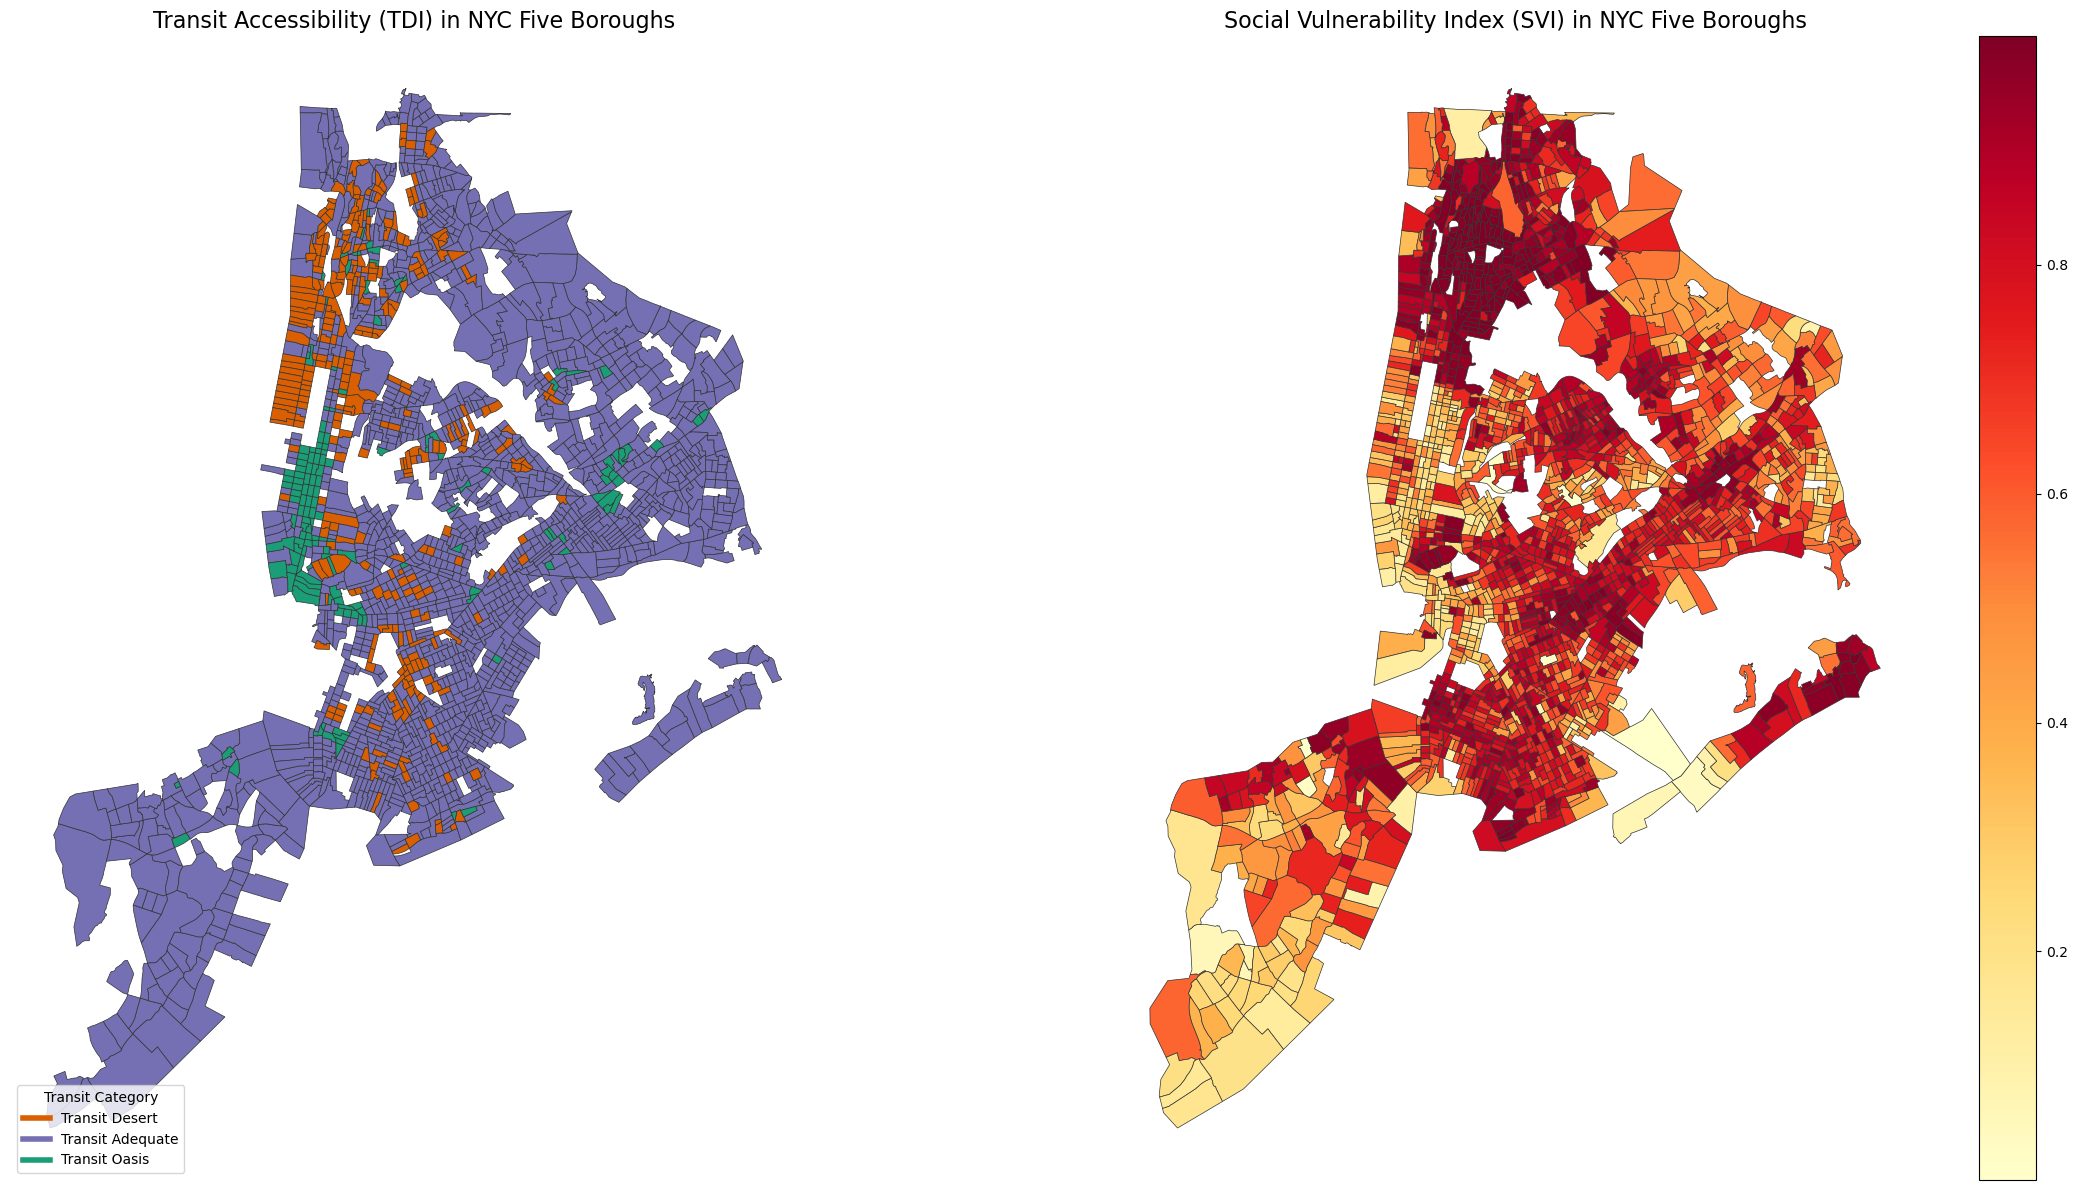

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(24, 12))  

# Defining a color mapping for each category
color_dict = {
    'Transit Desert': '#D95F02',    # Orange/red for deserts
    'Transit Adequate': '#7570B3',  # Purple for adequate areas
    'Transit Oasis': '#1B9E77'      # Green for oases
}

# Plot Transit Accessibility 
for category, data in nyc_tdi_zoomed_in.groupby('transit_category'):
    data.plot(
        color=color_dict[category],
        ax=axes[0],
        label=category,
        edgecolor='0.2',
        linewidth=0.5
    )

axes[0].set_title('Transit Accessibility (TDI) in NYC Five Boroughs', fontsize=16)
axes[0].axis('off')

# Add a legend for the transit categories manually 
custom_lines = [Line2D([0], [0], color=color_dict[cat], lw=4) for cat in color_dict]
axes[0].legend(custom_lines, color_dict.keys(), loc='lower left', title='Transit Category')


# Plot Social Vulnerability Index 
nyc_svi_zoomed_in.plot(
    column='RPL_THEMES',
    cmap='YlOrRd',
    legend=True,
    ax=axes[1],
    edgecolor='0.2',
    linewidth=0.5
)

axes[1].set_title('Social Vulnerability Index (SVI) in NYC Five Boroughs', fontsize=16)
axes[1].axis('off')

# Display the plot
plt.tight_layout()
plt.show()

---

## Sub-Question 2 
### Which specific aspects of social vulnerability (such as poverty, minority status, etc.) are most strongly associated with lower public transit accessibility? 

**Variables:**
* **_RPL_THEME1_**: Percentile ranking for Socioeconomic Status theme summary.
  * ACS varibles include:
    * **EP_POV150:**
      * Percentage of persons below 150% poverty estimate.
    * **EP_UNEMP**:
      * Unemployment rate estimate 
    * **EP_HBURD**:
      * Percentage of housing cost-burdened occupied housing units with annual income less than $75,000 (30%+ of income spent on housing costs) estimate. 
    * **EP_NOHSDP**:
      * Percentage of persons with no high school diploma (age 25+) estimate.
    * **EP_UNINSUR**:
      * Percentage uninsured in the total civilian noninstitutionalized population estimate. 
* **_RPL_THEME2_**: Percentile ranking for Household Characteristics theme summary.
  * ACS variables include:
    * **EP_AGE65**:
      * Percentage of persons aged 65 and older estimate.
    * **EP_AGE17**:
      * Percentage of persons aged 17 and younger estimate. 
    * **EP_DISABL**:
      * Percentage of civilian noninstitutionalized population with a disability estimate. 
    * **EP_SNGPNT**:
      * Percentage of single-parent households with children under 18 estimate. 
    * **EP_LIMENG**:
      * Percentage of persons (age 5+) who speak English "less than well" estimate. 
* **_RPL_THEME3_**: Percentile ranking for Racial and Ethnic Staus theme.
  * ACS variables include:
    * **EP_AFAM**:
      * Adjunct variable - Percentage of Black/African American, not Hispanic or Latino persons estimate. 
    * **EP_HISP**:
      * Adjunct variable - Percentage of Hispanic or Latino persons estimate. 
    * **EP_ASIAN**
      * Adjunct variable - Percentage of Asian, not Hispanic or Latino persons estimate
    * **EP_AIAN**:
      * Adjunct variable - Percentage of American Indian or Alaska Native, not Hispanic or Latino persons estimate.
    * **EP_NHPI**:
      * Adjunct variable - Percentage of Native Hawaiian or Other Pacific Islander, not Hispanic or Latino persons estimate.
    * **EP_TWOMORE**:
      * Adjunct variable - Percentage of two or more races, not Hispanic or Latino persons estimate.
    * **EP_OTHERRACE**:
      * Adjunct variable - Percentage of some other race, not Hispanic or Latino persons estimate. 
* **_RPL_THEME4_**: Percentile ranking for Housing Type/Transportation theme.
  * ACS variables include:
    * **EP_MUNIT**:
      * Percentage of housing in structures with 10 or more units estimate.
    * **EP_MOBILE**:
      * Percentage of mobile homes estimate.
    * **EP_CROWD**:
      * Percentage of occupied housing units with more people than rooms estimate. 
    * **EP_NOVEH**:
      * Percentage of households with no vehicle available estimate. 
    * **EP_GROUPQ**:
      * Percentage of persons in group quarters estimate. 
* **_td_index_**: Transit Desert Index - A standardized score measuring the gap between level of transit service (supply) and needs of the transportation-dependent population (demand).
  * **Interpretation:**
    * Values > 1: Transit desert (demand exceeds supply)
    * Values < -1: Transit oasis (supply exceeds demand)
    * Values between -1 and 1: Transit adequate (supply ≈ demand)
 
**NOTE**: For analyses of social vulnerability components, I use the EP variables (percentages) rather than E variables (raw counts). According to the CDC/ASTDR SVI 2022 documnetion, EP variables reprent the percentage of the population in each census tract affected by each vulnerability factor (e.g., percent below poverty, percent with a disability, etc). Therefore, using percentages allows for a more meaningful comparison across tracts of different population sizes. 

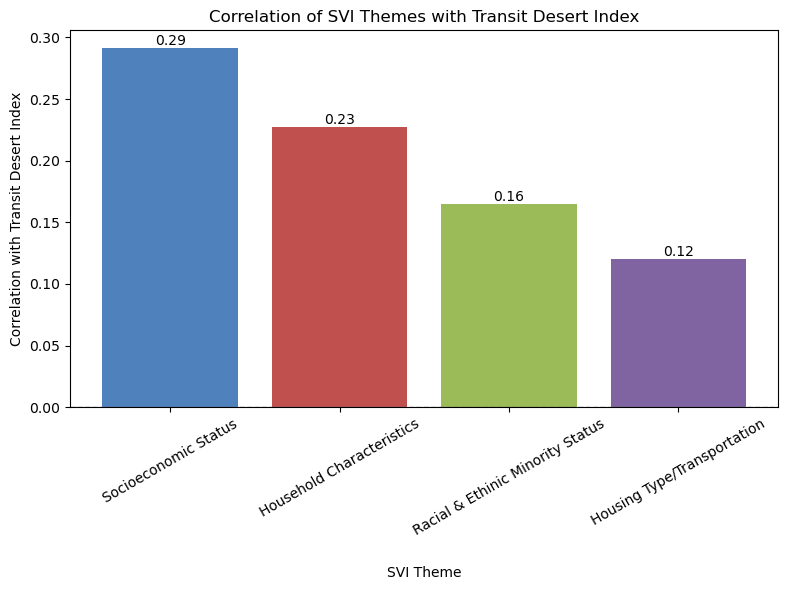

In [12]:
# Rename columns for clarity 
combined_nyc = combined_nyc.rename(columns={
    'RPL_THEME1': 'Socioeconomic Status',
    'RPL_THEME2': 'Household Characteristics',
    'RPL_THEME3': 'Racial & Ethinic Minority Status',
    'RPL_THEME4': 'Housing Type/Transportation'
})

# Define the theme variables 
theme_vars = [
    'Socioeconomic Status',
    'Household Characteristics',
    'Racial & Ethinic Minority Status',
    'Housing Type/Transportation'
]

# Calculate correlations
correlations = [combined_nyc['td_index'].corr(combined_nyc[var]) for var in theme_vars]

# Define separate colors for each RPL theme 
bar_colors = ['#4F81BD', '#C0504D', '#9BBB59', '#8064A2']

# Create bar chart
plt.figure(figsize=(8,6))
bars = plt.bar(theme_vars, correlations, color=bar_colors)
plt.ylabel('Correlation with Transit Desert Index')
plt.xlabel('SVI Theme', labelpad=20)
plt.title('Correlation of SVI Themes with Transit Desert Index')
plt.xticks(rotation=30)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)


# Add correlation coefficients on top of the bars
for bar, corr in zip(bars, correlations):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height,
             f'{corr:.2f}', ha='center', va='bottom', fontsize=10)

# Plot the bar chart 
plt.tight_layout()
plt.show()

In [13]:
# Define the ACS variables for each SVI theme
theme_components = {
    "Socioeconomic Status": ['EP_POV150', 'EP_HBURD', 'EP_UNEMP', 'EP_NOHSDP', 'EP_UNINSUR'],
    "Household Characteristics": ['EP_AGE65', 'EP_AGE17', 'EP_DISABL', 'EP_SNGPNT', 'EP_LIMENG'],
    "Racial & Ethnic Minority Status": ['EP_HISP', 'EP_AFAM', 'EP_AIAN', 'EP_ASIAN', 'EP_NHPI', 'EP_TWOMORE', 'EP_OTHERRACE'],
    "Housing Type & Transportation": ['EP_MUNIT', 'EP_MOBILE', 'EP_CROWD', 'EP_NOVEH', 'EP_GROUPQ']
}

In [14]:
# Calculate the correlation between 'td_index' and specified variables for each theme and store the results in a dataframe. 
correlation_rows = []
for theme, variables in theme_components.items():
    for var in variables:
        if var in combined_nyc.columns:
            corr = combined_nyc['td_index'].corr(combined_nyc[var])
            correlation_rows.append({
                "Theme": theme,
                "Variable": var,
                "Correlation": corr
            })

corr_df = pd.DataFrame(correlation_rows)

# Displaying correlation dataframe 
corr_df.head()

,Theme,Variable,Correlation
0,Socioeconomic Status,EP_POV150,0.211715
1,Socioeconomic Status,EP_HBURD,0.274518
2,Socioeconomic Status,EP_UNEMP,0.109879
3,Socioeconomic Status,EP_NOHSDP,0.221214
4,Socioeconomic Status,EP_UNINSUR,0.165746


In [15]:
# Mapping the variable names in 'corr_df' to descriptive labels using 'var_labels' and adds them as a new column 'Label'.
var_labels = {
    'EP_POV150': 'Below 150% Poverty',
    'EP_HBURD': 'Housing Cost Burden',
    'EP_UNEMP': 'Unemployed',
    'EP_NOHSDP': 'No High School Diploma',
    'EP_UNINSUR': 'No Health Insurance',
    'EP_AGE65': 'Aged 65+',
    'EP_AGE17': 'Aged <17',
    'EP_DISABL': 'Disability',
    'EP_SNGPNT': 'Single-Parent',
    'EP_LIMENG': 'Limited English',
    'EP_HISP': 'Hispanic/Latino',
    'EP_AFAM': 'Black',
    'EP_AIAN': 'American Indian/Alaska Native',
    'EP_ASIAN': 'Asian',
    'EP_NHPI': 'Native Hawaiian/Pacific Islander',
    'EP_TWOMORE': 'Two or More Races',
    'EP_OTHERRACE': 'Minority (any race)',
    'EP_MUNIT': 'Multi-Unit Structures',
    'EP_MOBILE': 'Mobile Homes',
    'EP_CROWD': 'Crowding',
    'EP_NOVEH': 'No Vehicle',
    'EP_GROUPQ': 'Group Quarters'
}
corr_df['Label'] = corr_df['Variable'].map(var_labels)

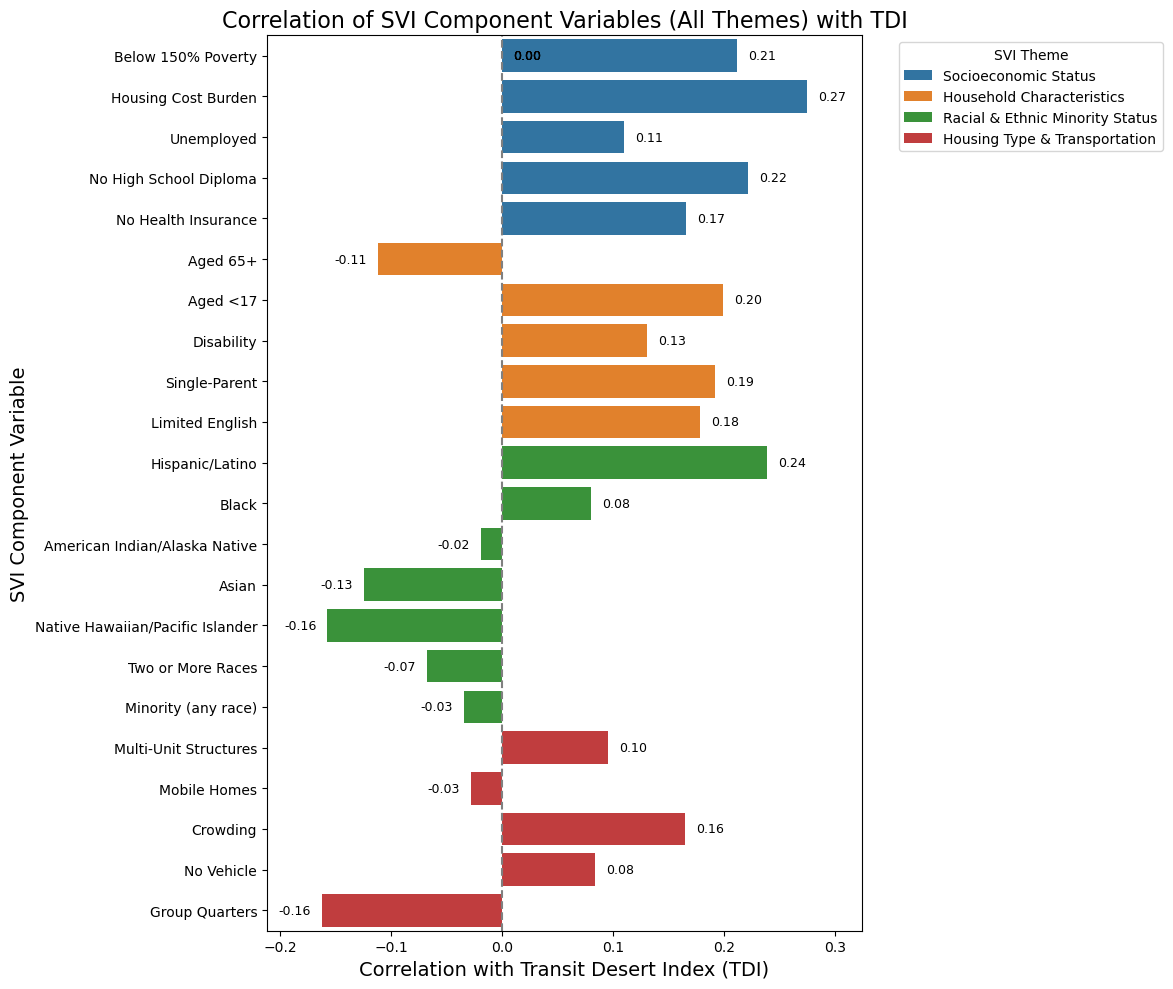

In [16]:
# Creating bar plot of correlation coefficients between each theme variable and TDI 
fig, ax = plt.subplots(figsize=(12, 10))
sns.barplot(
    data=corr_df,
    x='Correlation',
    y='Label',
    hue='Theme',
    dodge=False, 
    palette='tab10'
)

# Add vertical line at 0 for better visualization 
plt.axvline(0, color='gray', linestyle='--')

# Add labels and legend 
plt.xlabel('Correlation with Transit Desert Index (TDI)', fontsize=14)
plt.ylabel('SVI Component Variable', fontsize=14)
plt.title('Correlation of SVI Component Variables (All Themes) with TDI', fontsize=16)
plt.legend(title='SVI Theme', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add correlation values as labels on bars
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    ax.text(
        width + 0.01 if width >= 0 else width - 0.01, 
        y,
        f'{width:.2f}',
        va='center',
        ha='left' if width >= 0 else 'right',
        fontsize=9
    )

# Adjust x-axis limits to leave padding for text
min_corr, max_corr = corr_df['Correlation'].min(), corr_df['Correlation'].max()
padding = 0.05
ax.set_xlim(min_corr - padding, max_corr + padding)

# Plot the bar chart 
plt.tight_layout()
plt.show()